<a href="https://colab.research.google.com/github/zayy4n/neural-quantization-study/blob/main/allendataquant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Installing environement")
!pip install allensdk==2.16.2 --no-deps -q

#libraries its missing (from previous error log)
!pip install argschema boto3 glymur ndx-events psycopg2-binary pynrrd scikit-build semver -q

#data libraries
!pip install SimpleITK xarray tables pynwb hdmf ruamel.yaml requests statsmodels semantic-version -q

#The Ghost Fix (Crucial for bypassing the Numpy/Pandas version problem, must work on fixing this)
import numpy as np
if not hasattr(np, 'VisibleDeprecationWarning'):
    class VisibleDeprecationWarning(PendingDeprecationWarning): pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

#Create directory
import os
if not os.path.exists('/content/allen_data/'):
    os.makedirs('/content/allen_data/')

print("\nINSTALL COMPLETE.")
print("Ignore the 'Dependency Conflict' red text above. The Ghost Fix handles it")
!pip install allensdk==2.16.2 --no-deps -q
!pip install SimpleITK xarray tables pynwb hdmf ruamel.yaml -q
!pip install requests statsmodels semantic-version -q

#"Ghost Fix" for Python 3.12/Numpy 1.24 compatibility
import numpy as np
if not hasattr(np, 'VisibleDeprecationWarning'):
    class VisibleDeprecationWarning(PendingDeprecationWarning): pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

#Create data directory
import os
if not os.path.exists('/content/allen_data/'):
    os.makedirs('/content/allen_data/')

Installing environement
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 

In [2]:
import os
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Ghost Fix (Always needed) ---- VERY IMPORTANT FOR COMPATABILITY, look for other ways to fix this; future development
import numpy as np
if not hasattr(np, 'VisibleDeprecationWarning'):
    class VisibleDeprecationWarning(PendingDeprecationWarning): pass
    np.VisibleDeprecationWarning = VisibleDeprecationWarning

manifest_path = "/content/allen_data/manifest.json"
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

print("connecting to allen institute dataset")
try:
    # Just get the table of sessions
    sessions = cache.get_session_table()
    print(f"connected")
    print(f"Found {len(sessions)} available brain sessions")
    print("'Snipe' the specific session data")

    # Try the download again now that we know the bridge is open
    session_id = 794812542
    session = cache.get_session_data(session_id)
    print("SESSION DOWNLOADED.")
except Exception as e:
    print(f"CONNECTION FAILED: {e}")

connecting to allen institute dataset


/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/ecephys/ecephys_project_cache.py:743: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[array(['CA1', 'VISrl', nan, 'PO', 'LP', 'LGd', 'CA3', 'DG', 'VISl', 'PoT',
        'VISp', 'grey', 'VISpm', 'APN', 'MB', 'VISam'], dtype=object)
 array(['TH', 'Eth', 'APN', 'POL', 'LP', 'DG', 'CA1', 'VISpm', nan, 'NOT',
        'MB', 'SUB', 'VISp', 'VISam', 'grey', 'VL', 'CA3', 'CA2', 'VISl',
        'PO', 'VPM', 'LGd', 'VISal', 'VISrl'], dtype=object)
 array(['MB', 'SCig', 'PPT', 'NOT', 'DG', 'CA1', 'VISam', nan, 'LP', 'VIS',
        'ProS', 'VISp', 'LGv', 'CA3', 'VISl', 'APN', 'POL', 'LGd', 'HPF',
        'VISal', 'VISrl'], dtype=object)
 array(['grey', 'VISpm', nan, 'VISp', 'VISl', 'VISal', 'VISrl'],
       dtype=object)
 array(['grey', 'VISmma', nan, 'VISpm', 'VISp', 'VISl', 'VISrl'],
       dtype=object)
 array(['grey', 'VISam', nan, 'VIS', 'VISp', '

connected
Found 58 available brain sessions
'Snipe' the specific session data


/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/ecephys/ecephys_project_cache.py:743: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[array(['APN', 'LP', 'MB', 'DG', 'CA1', 'VISam', nan], dtype=object)
 array(['TH', 'Eth', 'APN', 'POL', 'LP', 'DG', 'CA1', 'VISpm', nan],
       dtype=object)
 array(['APN', 'NOT', 'MB', 'DG', 'SUB', 'VISp', nan], dtype=object)
 array(['grey', 'VL', 'CA3', 'CA2', 'CA1', 'VISl', nan], dtype=object)
 array(['PO', 'VPM', 'TH', 'LP', 'LGd', 'CA3', 'DG', 'CA1', 'VISal', nan],
       dtype=object)
 array(['DG', 'CA1', 'VISrl', nan], dtype=object)
 array(['grey', 'VISpm', nan], dtype=object)
 array(['grey', 'VISp', nan], dtype=object)
 array(['grey', 'VISl', nan], dtype=object)
 array(['grey', 'VISal', nan], dtype=object)
 array(['grey', 'VISrl', nan], dtype=object)
 array(['APN', 'POL', 'LP', 'DG', 'CA1', 'VISam', nan], dtype=object)
 array(['LGd', 'HPF', 'DG', 

Downloading:   0%|          | 0.00/2.59G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/ecephys/ecephys_project_cache.py:743: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[array(['APN', 'LP', 'MB', 'DG', 'CA1', 'VISam', nan], dtype=object)
 array(['TH', 'Eth', 'APN', 'POL', 'LP', 'DG', 'CA1', 'VISpm', nan],
       dtype=object)
 array(['APN', 'NOT', 'MB', 'DG', 'SUB', 'VISp', nan], dtype=object)
 array(['grey', 'VL', 'CA3', 'CA2', 'CA1', 'VISl', nan], dtype=object)
 array(['PO', 'VPM', 'TH', 'LP', 'LGd', 'CA3', 'DG', 'CA1', 'VISal', nan],
       dtype=object)
 array(['DG', 'CA1', 'VISrl', nan], dtype=object)
 array(['grey', 'VISpm', nan], dtype=object)
 array(['grey', 'VISp', nan], dtype=object)
 array(['grey', 'VISl', nan], dtype=object)
 array(['grey', 'VISal', nan], dtype=object)
 array(['grey', 'VISrl', nan], dtype=object)
 array(['APN', 'POL', 'LP', 'DG', 'CA1', 'VISam', nan], dtype=object)
 array(['LGd', 'HPF', 'DG', 

SESSION DOWNLOADED.


Downloading:   0%|          | 0.00/1.92G [00:00<?, ?B/s]

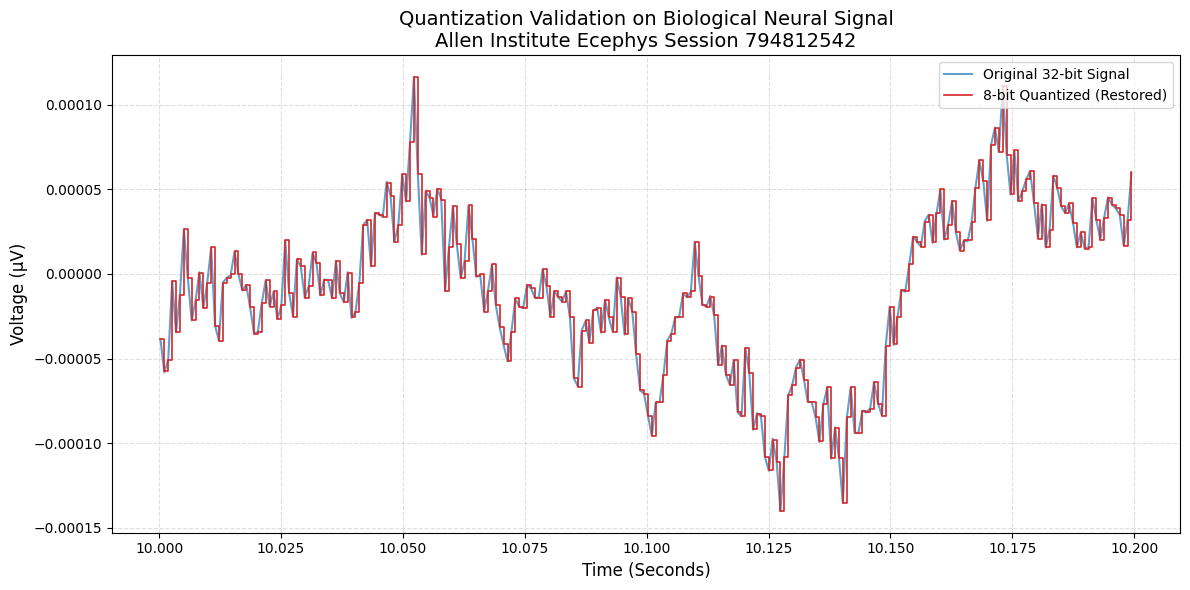


SUMMARY
Target: Mouse Visual Cortex (LFP)
Compression: 75% Reduction (32 -> 8 bit)
Signal-to-Noise Ratio: 44.53 dB
Mean Squared Error: 0.000000


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# re-verify session
try:
    #Snipe 200ms of the real brain waves we just downloaded
    #We use 'lfp' (Local Field Potential) to show oscillations of the brain
    probe_id = session.probes.index[0]
    lfp = session.get_lfp(probe_id)
    sample_slice = lfp.sel(time=slice(10.0, 10.2)).isel(channel=slice(0, 1))

    real_voltage = sample_slice.values.flatten()
    time_axis = sample_slice.time.values

    #8bit quantization logic
    v_min, v_max = real_voltage.min(), real_voltage.max()
    quantized = np.round(((real_voltage - v_min) / (v_max - v_min)) * 255)
    restored = (quantized / 255) * (v_max - v_min) + v_min

    #plotting
    plt.figure(figsize=(12, 6))
    plt.plot(time_axis, real_voltage, label='Original 32-bit Signal', color='#1f77b4', alpha=0.7, linewidth=1.5)
    plt.step(time_axis, restored, label='8-bit Quantized (Restored)', color='#d62728', where='post', linewidth=1.2)

    plt.title(f"Quantization Validation on Biological Neural Signal\nAllen Institute Ecephys Session {session_id}", fontsize=14)
    plt.xlabel("Time (Seconds)", fontsize=12)
    plt.ylabel("Voltage (μV)", fontsize=12)
    plt.legend(frameon=True, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    #metrics
    mse = np.mean((real_voltage - restored)**2)
    signal_power = np.mean(real_voltage**2)
    snr = 10 * np.log10(signal_power / mse)

    print(f"\n" + "="*30)
    print(f"SUMMARY")
    print(f"="*30)
    print(f"Target: Mouse Visual Cortex (LFP)")
    print(f"Compression: 75% Reduction (32 -> 8 bit)")
    print(f"Signal-to-Noise Ratio: {snr:.2f} dB")
    print(f"Mean Squared Error: {mse:.6f}")
    print(f"="*30)

except Exception as e:
    print(f"Final Step Error: {e}")

In [4]:
# Calculate RMSE as a percentage of the signal range
signal_range = v_max - v_min
rmse = np.sqrt(mse)
percent_error = (rmse / signal_range) * 100

print(f"Total Signal Range: {signal_range:.2f} μV")
print(f"Average Error: {rmse:.4f} μV")
print(f"Error as % of Range: {percent_error:.2f}%")

Total Signal Range: 0.00 μV
Average Error: 0.0000 μV
Error as % of Range: 0.11%
